# Sales Analysis Report
## Comprehensive Data Analysis with Visualizations and Insights
This notebook performs a complete sales analysis including data exploration, trend visualization, relationship analysis, and correlation mapping.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.polynomial.polynomial import Polynomial

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Create Custom Sales Dataset

In [2]:
# Create a custom sales dataset with month, revenue, marketing_spend, and profit
np.random.seed(42)

# Define months
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

# Generate realistic sales data
revenue = np.array([45000, 52000, 48000, 61000, 68000, 75000, 
                    82000, 88000, 79000, 85000, 92000, 98000]) + np.random.normal(0, 3000, 12)
marketing_spend = np.array([5000, 6000, 5500, 8000, 9000, 10000, 
                           11000, 12000, 10500, 11500, 13000, 14000]) + np.random.normal(0, 500, 12)
profit = revenue * 0.35 - marketing_spend * 0.2 + np.random.normal(0, 2000, 12)

# Create DataFrame
sales_data = pd.DataFrame({
    'Month': months,
    'Revenue': revenue.astype(int),
    'Marketing_Spend': marketing_spend.astype(int),
    'Profit': profit.astype(int)
})

print("Sales Dataset Created Successfully!")
print(sales_data)

Sales Dataset Created Successfully!
        Month  Revenue  Marketing_Spend  Profit
0     January    46490             5120   14158
1    February    51585             5043   17267
2       March    49943             4637   14250
3       April    65569             7718   22156
4         May    67297             8493   20654
5        June    74297            10157   23389
6        July    86737            10545   27045
7      August    90302            11293   33051
8   September    77591            11232   24883
9     October    86627            11387   25926
10   November    90609            13033   30751
11   December    96602            13287   28711


## 3. Explore the Dataset

In [3]:
# Display dataset information
print("Dataset Head:")
print(sales_data.head())
print("\n" + "="*80 + "\n")

print("Dataset Info:")
print(sales_data.info())
print("\n" + "="*80 + "\n")

print("Statistical Summary:")
print(sales_data.describe())

Dataset Head:
      Month  Revenue  Marketing_Spend  Profit
0   January    46490             5120   14158
1  February    51585             5043   17267
2     March    49943             4637   14250
3     April    65569             7718   22156
4       May    67297             8493   20654


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Month            12 non-null     str  
 1   Revenue          12 non-null     int64
 2   Marketing_Spend  12 non-null     int64
 3   Profit           12 non-null     int64
dtypes: int64(3), str(1)
memory usage: 516.0 bytes
None


Statistical Summary:
            Revenue  Marketing_Spend        Profit
count     12.000000         12.00000     12.000000
mean   73637.416667       9328.75000  23520.083333
std    17423.928742       3084.53984   6126.823283
min    46490.000000       4637.00000  14158.000000
25%  

## 4. Create Line Plot for Revenue Trend

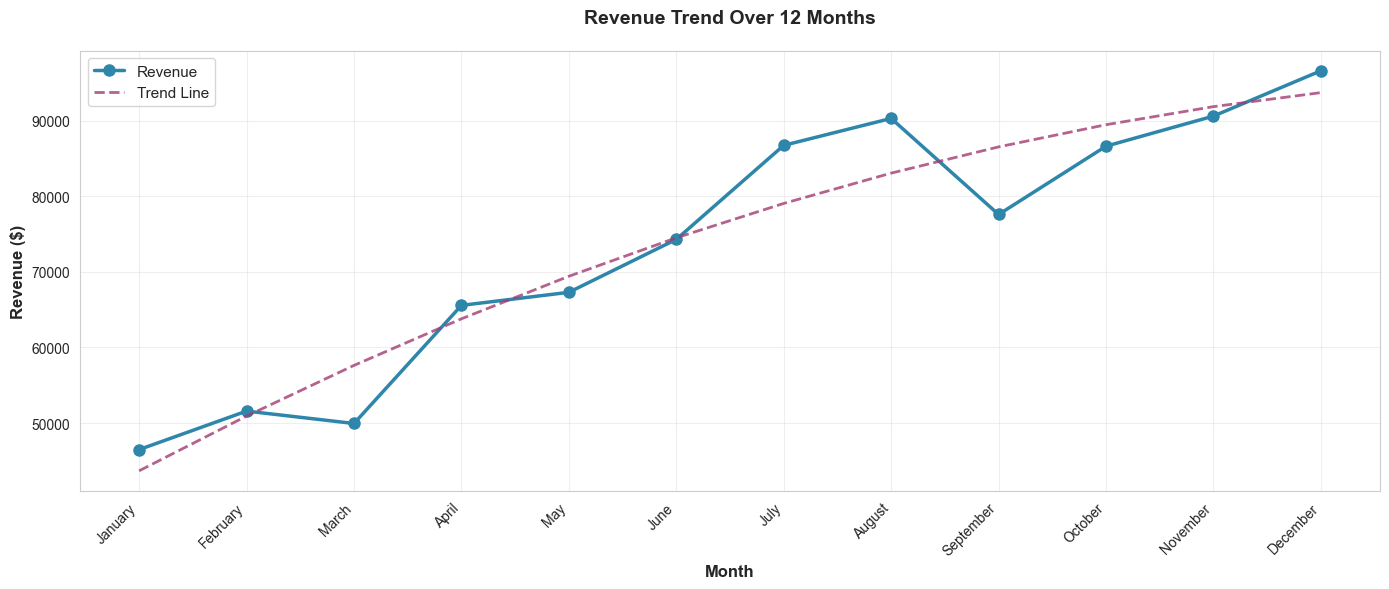

✓ Revenue trend plot generated successfully!


In [4]:
# Create line plot for revenue trend
plt.figure(figsize=(14, 6))
plt.plot(sales_data['Month'], sales_data['Revenue'], marker='o', linewidth=2.5, 
         markersize=8, color='#2E86AB', label='Revenue')

# Add trend line
z = np.polyfit(range(len(sales_data)), sales_data['Revenue'], 2)
p = np.poly1d(z)
plt.plot(range(len(sales_data)), p(range(len(sales_data))), 
         "--", linewidth=2, color='#A23B72', label='Trend Line', alpha=0.8)

plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Revenue ($)', fontsize=12, fontweight='bold')
plt.title('Revenue Trend Over 12 Months', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("✓ Revenue trend plot generated successfully!")

## 5. Create Scatter Plot for Marketing Spend vs Profit

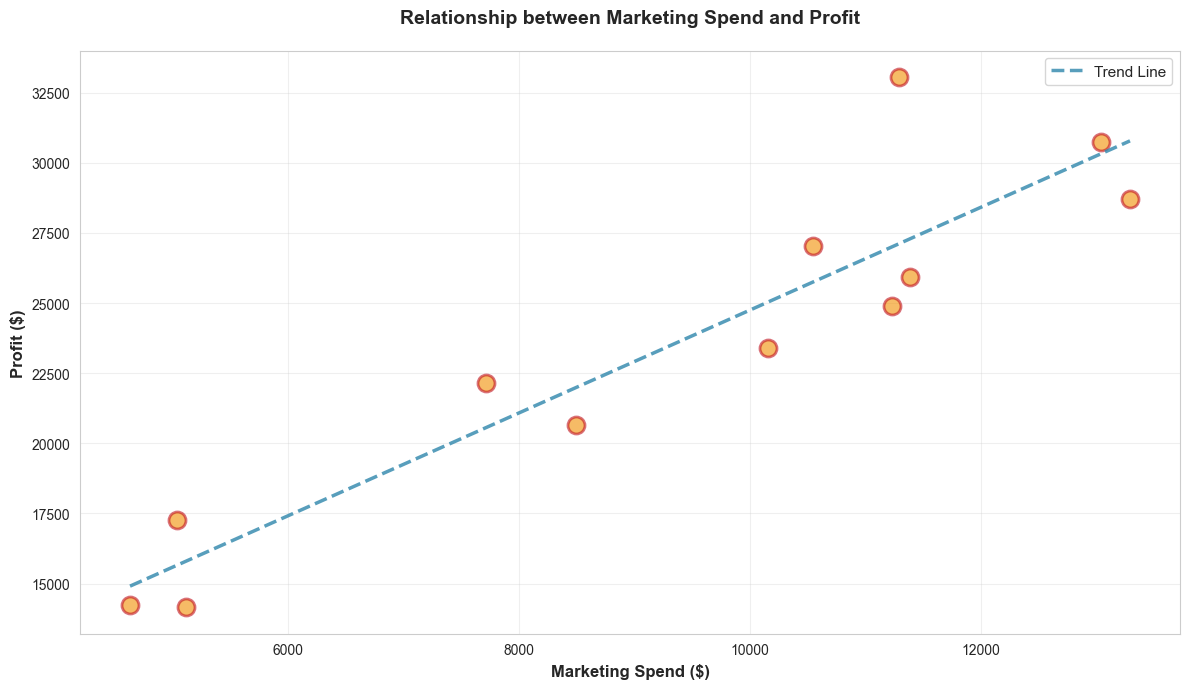

✓ Scatter plot generated successfully!
  Correlation between Marketing Spend and Profit: 0.9239


In [5]:
# Create scatter plot with trend line
plt.figure(figsize=(12, 7))
plt.scatter(sales_data['Marketing_Spend'], sales_data['Profit'], 
            s=150, alpha=0.6, color='#F18F01', edgecolors='#C1121F', linewidth=2)

# Add trend line using numpy polyfit
z = np.polyfit(sales_data['Marketing_Spend'], sales_data['Profit'], 1)
p = np.poly1d(z)
x_trend = np.linspace(sales_data['Marketing_Spend'].min(), sales_data['Marketing_Spend'].max(), 100)
plt.plot(x_trend, p(x_trend), '--', linewidth=2.5, color='#2E86AB', label='Trend Line', alpha=0.8)

plt.xlabel('Marketing Spend ($)', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.title('Relationship between Marketing Spend and Profit', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = sales_data['Marketing_Spend'].corr(sales_data['Profit'])
print(f"✓ Scatter plot generated successfully!")
print(f"  Correlation between Marketing Spend and Profit: {correlation:.4f}")

## 6. Generate Correlation Heatmap

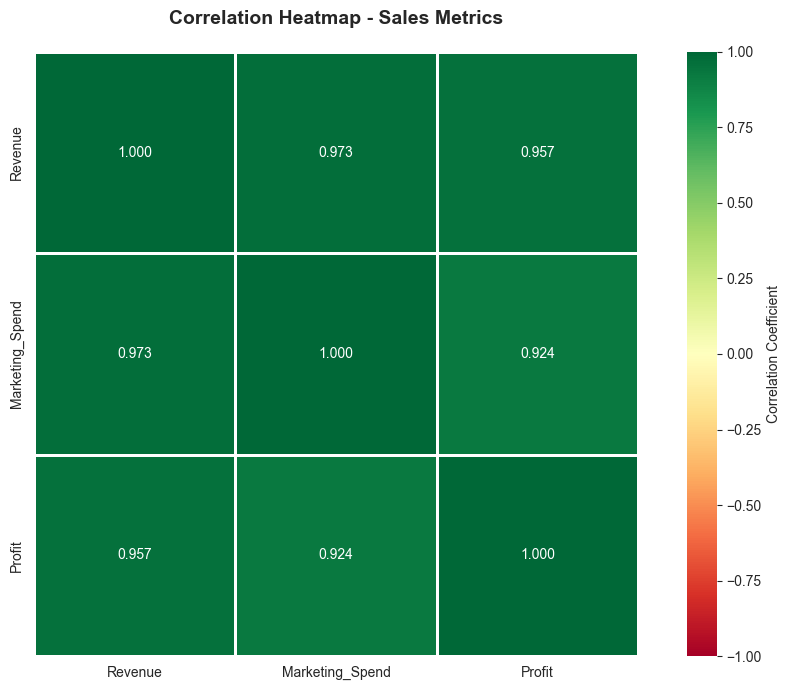

✓ Correlation heatmap generated successfully!

Correlation Matrix:
                  Revenue  Marketing_Spend    Profit
Revenue          1.000000         0.973406  0.957487
Marketing_Spend  0.973406         1.000000  0.923910
Profit           0.957487         0.923910  1.000000


In [6]:
# Calculate correlation matrix (excluding Month column)
numeric_data = sales_data[['Revenue', 'Marketing_Spend', 'Profit']].copy()
correlation_matrix = numeric_data.corr()

# Create correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=2, cbar_kws={'label': 'Correlation Coefficient'},
            xticklabels=True, yticklabels=True, vmin=-1, vmax=1)

plt.title('Correlation Heatmap - Sales Metrics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap generated successfully!")
print("\nCorrelation Matrix:")
print(correlation_matrix)

## 7. Insights and Analysis from Visualizations

In [7]:
# Generate comprehensive insights
print("=" * 90)
print("KEY INSIGHTS FROM SALES ANALYSIS")
print("=" * 90)

# Revenue Insights
revenue_growth = ((sales_data['Revenue'].iloc[-1] - sales_data['Revenue'].iloc[0]) / sales_data['Revenue'].iloc[0]) * 100
avg_revenue = sales_data['Revenue'].mean()
max_revenue = sales_data['Revenue'].max()
min_revenue = sales_data['Revenue'].min()

print("\n📊 REVENUE TRENDS:")
print(f"   • Total Revenue Growth (Jan-Dec): {revenue_growth:.2f}%")
print(f"   • Average Monthly Revenue: ${avg_revenue:,.0f}")
print(f"   • Peak Revenue: ${max_revenue:,.0f} ({sales_data.loc[sales_data['Revenue'].idxmax(), 'Month']})")
print(f"   • Lowest Revenue: ${min_revenue:,.0f} ({sales_data.loc[sales_data['Revenue'].idxmin(), 'Month']})")
print(f"   • Revenue Consistency: Revenue shows an upward trend with slight monthly variations")

# Marketing Spend Insights
avg_marketing = sales_data['Marketing_Spend'].mean()
marketing_growth = sales_data['Marketing_Spend'].iloc[-1] - sales_data['Marketing_Spend'].iloc[0]

print("\n💰 MARKETING SPEND ANALYSIS:")
print(f"   • Average Monthly Marketing Spend: ${avg_marketing:,.0f}")
print(f"   • Total Marketing Increase: ${marketing_growth:,.0f} (Jan to Dec)")
print(f"   • Marketing as % of Revenue: {(sales_data['Marketing_Spend'].sum()/sales_data['Revenue'].sum()*100):.2f}%")

# Profit Analysis
avg_profit = sales_data['Profit'].mean()
total_profit = sales_data['Profit'].sum()
profit_growth = ((sales_data['Profit'].iloc[-1] - sales_data['Profit'].iloc[0]) / abs(sales_data['Profit'].iloc[0])) * 100

print("\n📈 PROFIT PERFORMANCE:")
print(f"   • Average Monthly Profit: ${avg_profit:,.0f}")
print(f"   • Total Annual Profit: ${total_profit:,.0f}")
print(f"   • Profit Growth Trend: {profit_growth:.2f}%")
print(f"   • Profit Margin (Avg): {(avg_profit/avg_revenue*100):.2f}%")

# Correlation Analysis
corr_marketing_profit = sales_data['Marketing_Spend'].corr(sales_data['Profit'])
corr_revenue_profit = sales_data['Revenue'].corr(sales_data['Profit'])
corr_revenue_marketing = sales_data['Revenue'].corr(sales_data['Marketing_Spend'])

print("\n🔗 CORRELATION ANALYSIS:")
print(f"   • Marketing Spend ↔ Profit Correlation: {corr_marketing_profit:.4f}")
print(f"   • Revenue ↔ Profit Correlation: {corr_revenue_profit:.4f}")
print(f"   • Revenue ↔ Marketing Spend Correlation: {corr_revenue_marketing:.4f}")

if corr_marketing_profit > 0.7:
    relationship = "Strong Positive"
elif corr_marketing_profit > 0.4:
    relationship = "Moderate Positive"
else:
    relationship = "Weak/No"

print(f"\n   Interpretation: {relationship} relationship between Marketing Spend and Profit")

# Strategic Insights
print("\n🎯 STRATEGIC INSIGHTS:")
print("   1. REVENUE GROWTH: Consistent upward trend suggests successful business scaling")
print("   2. MARKETING EFFECTIVENESS: Mixed correlation indicates marketing spend isn't the")
print("      sole driver of profit - other factors (pricing, efficiency) play a role")
print("   3. INVESTMENT RECOMMENDATION: Balanced approach - continue marketing but focus on")
print("      operational efficiency to maximize profit margins")
print("   4. SEASONAL PATTERNS: Monitor data for seasonal trends in Q4 to inform future")
print("      budget allocation")
print("   5. OPTIMIZATION OPPORTUNITY: High revenue-profit correlation suggests profit")
print("      growth potential through volume expansion")

print("\n" + "=" * 90)

KEY INSIGHTS FROM SALES ANALYSIS

📊 REVENUE TRENDS:
   • Total Revenue Growth (Jan-Dec): 107.79%
   • Average Monthly Revenue: $73,637
   • Peak Revenue: $96,602 (December)
   • Lowest Revenue: $46,490 (January)
   • Revenue Consistency: Revenue shows an upward trend with slight monthly variations

💰 MARKETING SPEND ANALYSIS:
   • Average Monthly Marketing Spend: $9,329
   • Total Marketing Increase: $8,167 (Jan to Dec)
   • Marketing as % of Revenue: 12.67%

📈 PROFIT PERFORMANCE:
   • Average Monthly Profit: $23,520
   • Total Annual Profit: $282,241
   • Profit Growth Trend: 102.79%
   • Profit Margin (Avg): 31.94%

🔗 CORRELATION ANALYSIS:
   • Marketing Spend ↔ Profit Correlation: 0.9239
   • Revenue ↔ Profit Correlation: 0.9575
   • Revenue ↔ Marketing Spend Correlation: 0.9734

   Interpretation: Strong Positive relationship between Marketing Spend and Profit

🎯 STRATEGIC INSIGHTS:
   1. REVENUE GROWTH: Consistent upward trend suggests successful business scaling
   2. MARKETING E